# 使用 DQN 解决 CartPole-v1

本 Notebook 按照实验文档要求实现并训练一个 DQN 智能体，包括：

- Q 网络（MLP）与目标网络
- 经验回放（Replay Buffer）
- ε-greedy 探索与衰减
- 训练循环：采样、计算当前 Q 与目标 Q、反向传播更新
- 训练过程可视化：每回合奖励曲线、100 回合滑动平均曲线、损失曲线、ε 曲线
- 训练达到成功标准后自动停止，并进行贪心策略评估

> 说明：为提高稳定性，本实现使用 **Double DQN**（用主网络选动作、目标网络估值）+ **Huber Loss** + **梯度裁剪** + **软更新**。


## 1. 导入依赖

In [1]:
import random
import numpy as np
import math
from collections import deque, namedtuple
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
%matplotlib inline
import gymnasium as gym
GYMNASIUM = True

print("Using gymnasium:", GYMNASIUM)
print("Torch:", torch.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

Using gymnasium: True
Torch: 2.8.0+cu126


device(type='cuda')

## 2. 经验回放缓冲区（Replay Buffer）
存储经验元组 `(state, action, reward, next_state, done)`，支持 `push` 与 `sample`。


In [ ]:
Experience = namedtuple("Experience", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    def __init__(self, capacity: int, batch_size: int, seed: int = 0):
        self.buffer = deque(maxlen=capacity)
        self.batch_size = batch_size
        random.seed(seed)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Experience(state, action, reward, next_state, done))

    def sample(self):
        batch = random.sample(self.buffer, k=self.batch_size)

        states = torch.from_numpy(np.vstack([e.state for e in batch])).float().to(device)
        actions = torch.from_numpy(np.vstack([e.action for e in batch])).long().to(device)
        rewards = torch.from_numpy(np.vstack([e.reward for e in batch])).float().to(device)
        next_states = torch.from_numpy(np.vstack([e.next_state for e in batch])).float().to(device)
        dones = torch.from_numpy(np.vstack([e.done for e in batch]).astype(np.uint8)).float().to(device)
        
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


## 3. Q 网络（MLP）
输入为 4 维状态，输出为 2 个动作的 Q 值。至少一个隐藏层（此处两层）。


In [3]:
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_sizes=(128, 128)):
        super().__init__()
        layers = []
        in_dim = state_dim
        for h in hidden_sizes:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        layers += [nn.Linear(in_dim, action_dim)]
        self.net = nn.Sequential(*layers)

        # 小技巧：初始化可略微提升早期稳定性
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, a=math.sqrt(5))
                if m.bias is not None:
                    fan_in, _ = nn.init._calculate_fan_in_and_fan_out(m.weight)
                    bound = 1 / math.sqrt(fan_in)
                    nn.init.uniform_(m.bias, -bound, bound)

    def forward(self, x):
        return self.net(x)


## 4. DQN 智能体
包含主网络与目标网络；使用 ε-greedy；学习时采用 Double DQN 目标计算方式；目标网络软更新。


In [4]:
class DQNAgent:
    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 1e-3,
        gamma: float = 0.99,
        buffer_size: int = 100_000,
        batch_size: int = 64,
        tau: float = 1e-3,
        update_every: int = 1,
        seed: int = 0,
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.tau = tau
        self.update_every = update_every
        self.t_step = 0

        self.q_local = QNetwork(state_dim, action_dim).to(device)
        self.q_target = QNetwork(state_dim, action_dim).to(device)
        self.q_target.load_state_dict(self.q_local.state_dict())
        self.q_target.eval()

        self.optimizer = optim.Adam(self.q_local.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size, batch_size, seed=seed)

        self.loss_fn = nn.SmoothL1Loss()  # Huber loss

    def act(self, state: np.ndarray, eps: float = 0.0) -> int:
        """ε-greedy 选动作"""
        if random.random() < eps:
            return random.randrange(self.action_dim)

        state_t = torch.from_numpy(state).float().unsqueeze(0).to(device)
        self.q_local.eval()
        with torch.no_grad():
            q_values = self.q_local(state_t)
        self.q_local.train()

        return int(torch.argmax(q_values, dim=1).item())

    def step(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

        self.t_step = (self.t_step + 1) % self.update_every
        if self.t_step == 0 and len(self.memory) >= self.batch_size:
            return self.learn(self.memory.sample())
        return None

    def learn(self, experiences):
        states, actions, rewards, next_states, dones = experiences

        # 当前 Q(s,a)
        q_expected = self.q_local(states).gather(1, actions)

        # Double DQN：
        # 1) 用主网络在 next_states 上选 a' = argmax_a Q_local(next_state, a)
        # 2) 用目标网络估值 Q_target(next_state, a')
        with torch.no_grad():
            next_actions = torch.argmax(self.q_local(next_states), dim=1, keepdim=True)
            q_next = self.q_target(next_states).gather(1, next_actions)
            q_target = rewards + (1 - dones) * self.gamma * q_next

        loss = self.loss_fn(q_expected, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_local.parameters(), max_norm=10.0)
        self.optimizer.step()

        # 软更新目标网络
        self.soft_update(self.q_local, self.q_target, self.tau)

        return float(loss.item())

    @staticmethod
    def soft_update(local_model, target_model, tau: float):
        for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
            target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)


## 5. 训练函数
当连续 100 回合平均奖励 ≥ 195 时停止训练。


In [5]:
def make_env(seed=0):
    env = gym.make("CartPole-v1")
    if GYMNASIUM:
        env.reset(seed=seed)
        env.action_space.seed(seed)
        env.observation_space.seed(seed)
    else:
        env.seed(seed)
    return env

def unwrap_step(env, action):
    """兼容 gym 与 gymnasium step 返回格式"""
    out = env.step(action)
    if GYMNASIUM:
        next_state, reward, terminated, truncated, info = out
        done = terminated or truncated
        return next_state, reward, done, info
    else:
        next_state, reward, done, info = out
        return next_state, reward, done, info

def unwrap_reset(env):
    out = env.reset()
    if GYMNASIUM:
        state, info = out
        return state
    else:
        state = out
        return state

def train_dqn(
    n_episodes: int = 2000,
    max_t: int = 500,
    eps_start: float = 1.0,
    eps_end: float = 0.05,
    eps_decay: float = 0.995,
    print_every: int = 20,
):
    env = make_env(SEED)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = DQNAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        lr=1e-3,
        gamma=0.99,
        buffer_size=100_000,
        batch_size=64,
        tau=1e-3,
        update_every=1,
        seed=SEED,
    )

    scores = []
    scores_window = deque(maxlen=100)
    losses = []
    epsilons = []

    eps = eps_start

    log_path = "train.log"
    with open(log_path, "w", encoding="utf-8") as f_log:

        def log(msg: str):
            print(msg)
            f_log.write(msg + "\n")
            f_log.flush()

        for i_episode in range(1, n_episodes + 1):
            state = unwrap_reset(env)
            score = 0.0
            ep_losses = []

            for t in range(max_t):
                action = agent.act(state, eps)
                next_state, reward, done, _ = unwrap_step(env, action)

                loss = agent.step(state, action, reward, next_state, done)
                if loss is not None:
                    ep_losses.append(loss)

                state = next_state
                score += reward
                if done:
                    break

            scores_window.append(score)
            scores.append(score)
            losses.append(np.mean(ep_losses) if len(ep_losses) > 0 else np.nan)
            eps = max(eps_end, eps_decay * eps)
            epsilons.append(eps)

            if i_episode % print_every == 0:
                avg100 = np.mean(scores_window)
                log(f"Episode {i_episode:4d} | Avg(100) = {avg100:6.2f} | eps = {eps:5.3f}")

            if np.mean(scores_window) >= 195.0 and i_episode >= 100:
                log(f"\nSolved! Episode {i_episode} | Avg(100) = {np.mean(scores_window):.2f}")
                break

    env.close()
    return agent, scores, losses, epsilons


## 6. 开始训练


In [6]:
agent, scores, losses, epsilons = train_dqn(
    n_episodes=2000,
    max_t=500,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.995,
    print_every=20,
)


Episode   20 | Avg(100) =  21.30 | eps = 0.905
Episode   40 | Avg(100) =  20.12 | eps = 0.818
Episode   60 | Avg(100) =  20.92 | eps = 0.740
Episode   80 | Avg(100) =  20.51 | eps = 0.670
Episode  100 | Avg(100) =  22.55 | eps = 0.606
Episode  120 | Avg(100) =  25.08 | eps = 0.548
Episode  140 | Avg(100) =  27.92 | eps = 0.496
Episode  160 | Avg(100) =  36.38 | eps = 0.448
Episode  180 | Avg(100) =  42.66 | eps = 0.406
Episode  200 | Avg(100) =  49.50 | eps = 0.367
Episode  220 | Avg(100) =  58.54 | eps = 0.332
Episode  240 | Avg(100) =  70.34 | eps = 0.300
Episode  260 | Avg(100) =  76.93 | eps = 0.272
Episode  280 | Avg(100) =  82.65 | eps = 0.246
Episode  300 | Avg(100) =  88.63 | eps = 0.222
Episode  320 | Avg(100) =  92.06 | eps = 0.201
Episode  340 | Avg(100) = 101.91 | eps = 0.182
Episode  360 | Avg(100) = 112.24 | eps = 0.165
Episode  380 | Avg(100) = 116.91 | eps = 0.149
Episode  400 | Avg(100) = 120.84 | eps = 0.135
Episode  420 | Avg(100) = 131.37 | eps = 0.122
Episode  440 

## 7. 可视化：奖励曲线、100 回合滑动平均、损失曲线、ε 曲线


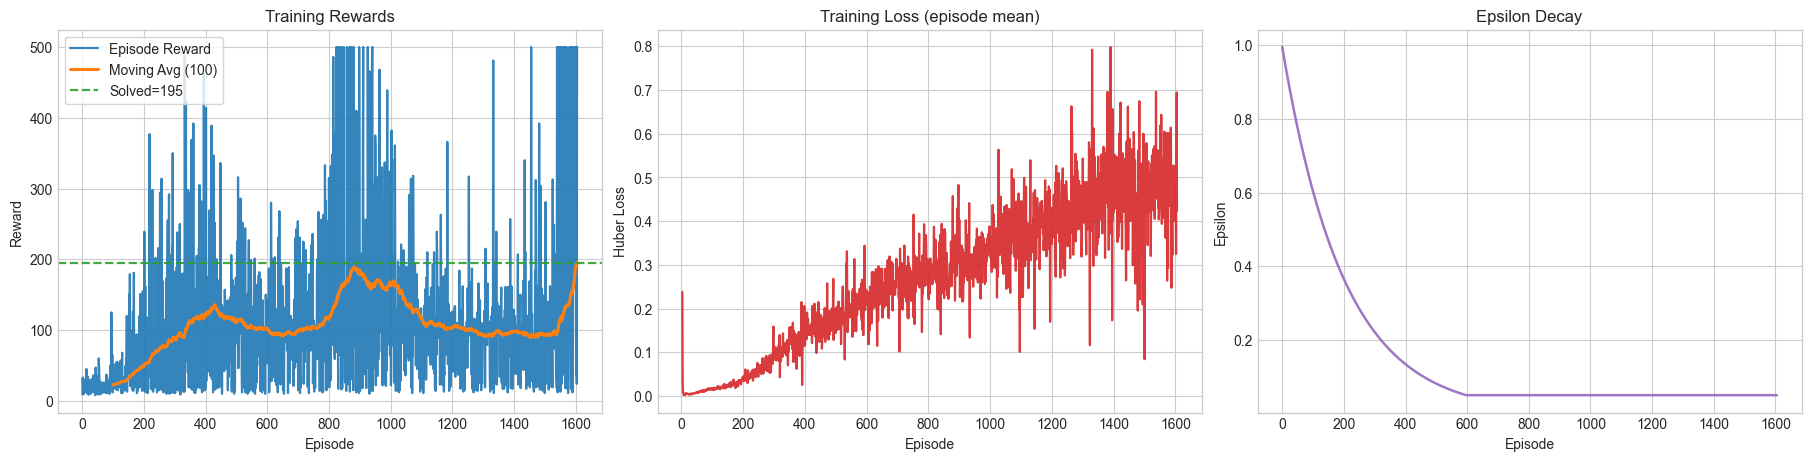

Final Avg(100): 196.16000000000003


In [7]:
def moving_average(x, window=100):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < window:
        return np.array([])
    return np.convolve(x, np.ones(window) / window, mode="valid")

ma100 = moving_average(scores, 100)

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

# 1) Rewards + Moving Avg
ax = axes[0]
ax.plot(scores, color="tab:blue", linewidth=1.6, alpha=0.9, label="Episode Reward")
if len(ma100) > 0:
    ax.plot(
        np.arange(99, 99 + len(ma100)),
        ma100,
        color="tab:orange",
        linewidth=2.2,
        label="Moving Avg (100)",
    )
ax.axhline(195, color="tab:green", linestyle="--", linewidth=1.6, alpha=0.9, label="Solved=195")
ax.set_title("Training Rewards")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.legend(frameon=True)

# 2) Loss
ax = axes[1]
ax.plot(losses, color="tab:red", linewidth=1.6, alpha=0.9)
ax.set_title("Training Loss (episode mean)")
ax.set_xlabel("Episode")
ax.set_ylabel("Huber Loss")

# 3) Epsilon
ax = axes[2]
ax.plot(epsilons, color="tab:purple", linewidth=1.8, alpha=0.9)
ax.set_title("Epsilon Decay")
ax.set_xlabel("Episode")
ax.set_ylabel("Epsilon")

plt.show()

if len(ma100) > 0:
    print("Final Avg(100):", float(ma100[-1]))
else:
    print("Not enough episodes to compute Avg(100).")


## 8. 评估并录制智能体表现


In [8]:
from pathlib import Path
import datetime

@torch.no_grad()
def record_agent_video(agent, episodes: int = 1, max_t: int = 500, fps: int = 30, name_prefix: str = "dqn_cartpole"):
    """
    使用训练好的 agent 录制视频到当前 notebook 同目录。
    - gymnasium: RecordVideo + render_mode="rgb_array"
    - 输出: mp4 文件（通常在 video_folder 下）
    """

    out_dir = Path.cwd() / "videos"
    out_dir.mkdir(parents=True, exist_ok=True)

    # 创建环境（rgb_array 用于录制）
    env = gym.make("CartPole-v1", render_mode="rgb_array")

    # 录制：episode_trigger= lambda i: True 表示每回合都录
    env = gym.wrappers.RecordVideo(
        env,
        video_folder=str(out_dir),
        episode_trigger=lambda ep_id: True,
        name_prefix=f"{name_prefix}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}",
        fps=fps,
        disable_logger=True,
    )

    agent.q_local.eval()

    for ep in range(episodes):
        state, _ = env.reset(seed=SEED + 30000 + ep)
        total_r = 0.0

        for t in range(max_t):
            # 贪心动作
            action = agent.act(state, eps=0.0)
            next_state, r, done, _ = unwrap_step(env, action)
            total_r += float(r)
            state = next_state
            if done:
                break

    env.close()
    agent.q_local.train()

    print(f"Videos saved to: {out_dir}")
    # 列出生成的视频文件
    mp4s = sorted(out_dir.glob("*.mp4"))
    if mp4s:
        print("Generated files:")
        for p in mp4s[-5:]:
            print(" -", p.name)
    else:
        print("No mp4 found. If you see .webm files, check your gymnasium/video backend.")

record_agent_video(agent, episodes=3, fps=30)

d:\miniconda3\envs\wjl\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at d:\Desktop\DL\exp-4\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Videos saved to: d:\Desktop\DL\exp-4\videos
Generated files:
 - dqn_cartpole_20260113_163041-episode-0.mp4
 - dqn_cartpole_20260113_163041-episode-1.mp4
 - dqn_cartpole_20260113_163041-episode-2.mp4


## 9. 实验报告撰写要点
- **算法简介**：DQN 使用神经网络近似动作价值函数 Q(s,a)，结合经验回放与目标网络稳定训练。
- **实现细节**：
  - 网络：MLP(4 → 128 → 128 → 2)，ReLU 激活；
  - 经验回放：容量 100,000，batch 64；
  - 折扣因子 γ=0.99，学习率 1e-3，优化器 Adam；
  - ε-greedy：ε 从 1.0 衰减到 0.05（每回合乘 0.995）；
  - 目标网络：软更新 τ=1e-3；
  - 稳定性增强：Double DQN + Huber Loss + 梯度裁剪。
- **结果与分析**：
  - 展示奖励曲线与 100 回合滑动平均曲线；
  - 展示损失曲线与 ε 衰减曲线；
  - 指出达到 Avg(100)≥195 的回合数以及训练收敛表现。